# 1. Load Data

In [ ]:
"""Cluster Latent Space

Structure:
    1.1. Imports, Variables, Functions
    1.2. Load Data
"""

# 1.1 Imports, Variables, Functions
# imports
import sys

sys.path.append("exp/utils_exp")
from utils_exp import utils as ut
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys

sys.path.append(os.path.join("..", ".."))
# # from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io

logging.basicConfig(level=logging.INFO)
import importlib
import scanpy as sc
from src.utils import utils

importlib.reload(ut)
importlib.reload(vz)


# variables
# run_dir = os.path.join("..","..","outputs","run-25-09-28-05")
# run_dir = os.path.join("..", "..", "outputs", "run-25-09-13-18")  # RNA-seq
# run_dir = os.path.join("..","..","outputs","run-25-10-05-01")
run_dir = os.path.join("..","..","outputs","run-25-09-17-01") # Microarray

embedding_types = ["ft","pt", "raw_normed"]


# functions
def get_counts(df: pd.DataFrame, rel_map: Dict, key_interest: str) -> pd.DataFrame:
    df_query = df.copy()

    n_same, n_rel, n_unrel, n_total, n_universe_related, n_total_unique = (
        [],
        [],
        [],
        [],
        [],
        [],
    )
    n_same_uniq, n_rel_uniq = [], []

    for _, r in df_query.iterrows():
        topk = list(r[key_interest])  # keep duplicates
        doid = r["query_doid"]
        related = rel_map.get(doid, set())

        same = sum(1 for x in topk if x == doid)  # absolute count of the exact disease
        rel = sum(
            1 for x in topk if x in related
        )  # absolute count of related diseases (counts repeats)
        total = len(topk)
        unrel = total - same - rel

        n_same.append(same)
        n_same_uniq.append(len(set(topk) & {doid}))
        n_rel.append(rel)
        n_rel_uniq.append(len(set(topk) & related))
        n_unrel.append(unrel)
        n_total.append(total)
        n_universe_related.append(len(related) + 1)  # +1 to include self
        n_total_unique.append(len(set(topk)))

    df_query["n_same"] = n_same
    df_query["n_rel"] = n_rel
    df_query["n_unrel"] = n_unrel
    df_query["n_total"] = n_total
    df_query["n_universe_related"] = n_universe_related
    df_query["n_total_unique"] = n_total_unique
    df_query["n_same_uniq"] = n_same_uniq
    df_query["n_rel_uniq"] = n_rel_uniq

    df_query["pct_same"] = df_query["n_same"] / df_query["n_total"] * 100
    df_query["pct_rel"] = df_query["n_rel"] / df_query["n_total"] * 100
    df_query["pct_unrel"] = df_query["n_unrel"] / df_query["n_total"] * 100

    df_query["hits_same"] = (df_query["n_same"] > 0).astype(int)
    df_query["hits_rel"] = (df_query["n_rel"] > 0).astype(int)

    # get precision
    # df_query["prec@k"] = (df_query["n_rel"]+df_query["n_same"]) / df_query["n_total"]

    df_query["old_prec@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_total"
    ]
    df_query["old_recall@k"] = (df_query["n_rel"] + df_query["n_same"]) / df_query[
        "n_universe_related"
    ]
    df_query["prec@k"] = (df_query["n_rel_uniq"] + df_query["n_same_uniq"]) / df_query[
        "n_total_unique"
    ]
    df_query["recall@k"] = (
        df_query["n_rel_uniq"] + df_query["n_same_uniq"]
    ) / df_query["n_universe_related"]

    return df_query


# 1.2 Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

/aloy/home/ddalton/miniconda3/envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded variable predictions_test
Loaded variable labels_test
Loaded variable results_test
Loaded variable all_outputs_test
Loaded variable predictions_valid
Loaded variable labels_valid
Loaded variable results_valid
Loaded variable all_outputs_valid
Loaded variable predictions_train
Loaded variable labels_train
Loaded variable results_train
Loaded variable all_outputs_train
Loaded variable adata_orig
Loaded variable id2type
Loaded variable train_indices
Loaded variable valid_indices
Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT

In [2]:
split_idx = 0

# load all adata
adata_test = sc.read(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)
adata_valid = sc.read(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)
adata_train = sc.read(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)

In [ ]:
embedding_trains = list()
embeddings_valids = list()
embeddings_tests = list()
for embedding_type in embedding_types:


    if embedding_type == "ft":
        run_name = run_dir.split("/")[-1]
        output_dir = os.path.join(run_dir, "outputs")
    elif embedding_type == "pt":
        run_name = run_dir.split("/")[-1]
        output_dir = os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
        )
    elif embedding_type == "raw":
        run_name = run_dir.split("/")[-1]
        output_dir = os.path.join(
            "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/", run_name, "outputs"
        )

    # load scGPT embeddings
    print(f"Using {embedding_type} embeddings")
    if embedding_type == "ft":
        embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
        embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
        embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
        print(f"Loaded ft embeddings from all_outputs")
    elif embedding_type == "pt":
        # pt_adata_test = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_test_1.h5ad"))
        # pt_adata_valid = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_valid_1.h5ad"))
        # pt_adata_train = sc.read(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name,"pt_adata_train_1.h5ad"))
        # embeddings_test = pt_adata_test.obsm["X_scGPT"]
        # embeddings_valid = pt_adata_valid.obsm["X_scGPT"]
        # embeddings_train = pt_adata_train.obsm["X_scGPT"]

        embeddings_test = np.load(
            os.path.join(
                "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
                run_name,
                "test-pt_embeddings.npy",
            )
        )
        embeddings_valid = np.load(
            os.path.join(
                "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
                run_name,
                "valid-pt_embeddings.npy",
            )
        )
        embeddings_train = np.load(
            os.path.join(
                "/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",
                run_name,
                "train-pt_embeddings.npy",
            )
        )
        print(f"Loaded pt embeddings from npy files")
    elif embedding_type == "raw":
        embeddings_test = np.array(adata_test.X)
        embeddings_valid = np.array(adata_valid.X)
        embeddings_train = np.array(adata_train.X)

        # replace nans with 0
        embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
        embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
        embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)
        print(f"Loaded raw embeddings from adata.X")

    elif embedding_type == "raw_normed":
        embeddings_test = np.array(adata_test.layers["X_normed"])
        embeddings_valid = np.array(adata_valid.layers["X_normed"])
        embeddings_train = np.array(adata_train.layers["X_normed"])

        # replace nans with 0
        embeddings_test = np.nan_to_num(embeddings_test, nan=0.0)
        embeddings_valid = np.nan_to_num(embeddings_valid, nan=0.0)
        embeddings_train = np.nan_to_num(embeddings_train, nan=0.0)

        print(f"Loaded raw normalized embeddings from adata.X")

    
    embedding_trains.append(embeddings_train)
    embeddings_valids.append(embeddings_valid)
    embeddings_tests.append(embeddings_test)

Using ft embeddings
Loaded ft embeddings from all_outputs
Using pt embeddings


FileNotFoundError: [Errno 2] No such file or directory: '/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-17-01/test-pt_embeddings.npy'

In [ ]:
# Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = utils.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}")

# Load IC based similarity
do_graph = utils.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}

Loaded universe of disease pairs: 70442515


In [ ]:
# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(
    f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}"
)


# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}"
)
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(
    f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}"
)
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215
Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


In [ ]:
# map doid to related diseases
rel_map = {}
for thr in [0.396, 0.6, 0.8, 0.9]:
    rel_map[thr] = dict()
    _do_df = do_df_ic_query.query(f"lin >= {thr}")

    for d in d_ids:
        rel_map[thr][d] = set(_do_df.loc[_do_df["do1"] == d, "do2"]) | set(
            _do_df.loc[_do_df["do2"] == d, "do1"]
        )

In [ ]:
_do_df = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")

lin_map = dict()
for _,row in _do_df.iterrows():
    do1 = row["do1"]
    do2 = row["do2"]
    lin = row["lin"] 
    if do1 not in lin_map:
        lin_map[do1] = dict()
    if do2 not in lin_map:
        lin_map[do2] = dict()
    lin_map[do1][do2] = lin
    lin_map[do2][do1] = lin

# 2. Process Data

In [ ]:
# imports
import importlib

importlib.reload(ut)

# variables
remove_control_train = True
remove_control_test = True
custom_splits = False
merge_train_valid = False
thr_related = 1.0


# functions
def custom_train_valid_split(
    df, random_state=42, remove_control: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    """
    For each disease:
      - If multiple datasets exist → split by dataset (1 dataset → valid)
        and also split CONTROL samples belonging to the same datasets.
      - Otherwise → split disease samples by individual rows (1 sample → valid).
    """
    rng = np.random.default_rng(random_state)
    train_idx, valid_idx = [], []

    if not remove_control:
        df_controls = df[df["doid_id"] == "Control"]

    valid_datasets = set()
    train_datasets = set()
    # Loop through diseases
    for doid in df["doid_id"].unique():
        if doid == "Control":
            continue  # df_controls handled when splitting real diseases

        df_do = df[df["doid_id"] == doid]
        datasets = df_do["dataset"].unique()

        n_overlap_valid = len(valid_datasets & set(datasets))
        if (n_overlap_valid > 0) & (
            len(datasets) - n_overlap_valid
        ) > 0:  # if dataset already placed in valid set

            # place existing dataset in valid for this disease
            valid_idx.extend(df_do[df_do["dataset"].isin(valid_datasets)].index)
            train_idx.extend(df_do[~df_do["dataset"].isin(valid_datasets)].index)

        elif len(datasets) - n_overlap_valid > 1:
            rng.shuffle(list(datasets))
            new_valid_datasets = {
                d for d in datasets if d not in valid_datasets
            }  # datasets not already in valid
            new_valid_datasets = {
                list(new_valid_datasets)[0]
            }  # take one new dataset for valid
            new_train_datasets = set(datasets) - new_valid_datasets - valid_datasets

            # disease samples
            valid_idx.extend(df_do[df_do["dataset"].isin(new_valid_datasets)].index)
            train_idx.extend(df_do[df_do["dataset"].isin(new_train_datasets)].index)

            valid_datasets.update(new_valid_datasets)
            train_datasets.update(new_train_datasets)

            if not remove_control:
                # matching CONTROL samples for those datasets
                ctrl_valid = df_controls[
                    df_controls["dataset"].isin(new_valid_datasets)
                ].index
                ctrl_train = df_controls[
                    df_controls["dataset"].isin(new_train_datasets)
                ].index

                valid_idx.extend(ctrl_valid)
                train_idx.extend(ctrl_train)
        else:
            idx = df_do.index.to_numpy()
            rng.shuffle(idx)
            n_valid_ds = max(1, len(idx) // 6)
            valid_idx.append(idx[n_valid_ds - 1])
            train_idx.extend(idx[n_valid_ds:])

            # controls for this dataset (if available)
            ds = df_do["dataset"].iloc[0]

            if not remove_control:
                ctrl_ds = df_controls[df_controls["dataset"] == ds].index.to_numpy()

                if len(ctrl_ds) > 0:
                    rng.shuffle(ctrl_ds)
                    n_valid_ds = max(1, len(ctrl_ds) // 6)
                    valid_idx.append(ctrl_ds[n_valid_ds - 1])
                    train_idx.extend(ctrl_ds[n_valid_ds:])

    return np.array(train_idx), np.array(valid_idx)


# prepare data
all_doids = sorted(adata_train.obs["doid_id"].unique())

df_trains = list()
df_valids = list()
df_tests = list()

e_trains = list()
e_valids = list()
e_tests = list()

y_trains = list()
y_valids = list()
y_tests = list()

for i, embedding_type in enumerate(embedding_types):
    print(f"Preparing data for embedding type: {embedding_type}")
    e_train = embedding_trains[i]
    e_valid = embeddings_valids[i]
    e_test = embeddings_tests[i]

    df_train = adata_train.obs.copy()
    df_valid = adata_valid.obs.copy()
    df_test = adata_test.obs.copy()


    if remove_control_train:
        
        all_doids.remove("Control") if "Control" in all_doids else None

        mask_train = df_train["doid_id"] != "Control"
        mask_valid = df_valid["doid_id"] != "Control"

        e_train = e_train[mask_train.values]
        e_valid = e_valid[mask_valid.values]

        df_train = df_train[mask_train].reset_index(drop=True)
        df_valid = df_valid[mask_valid].reset_index(drop=True)

    if remove_control_test:
        mask_test = df_test["doid_id"] != "Control"

        e_test = e_test[mask_test.values]

        df_test = df_test[mask_test].reset_index(drop=True)


    if custom_splits:
        df_train_all = pd.concat(
            [df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0
        )
        df_train_all = df_train_all.reset_index(drop=True)

        # RE-SPLIT TRAIN/VALIDATION SET
        train_idx, valid_idx = custom_train_valid_split(
            df_train_all, remove_control=remove_control_train
        )
        df_train = df_train_all.iloc[train_idx].reset_index(drop=True)
        df_valid = df_train_all.iloc[valid_idx].reset_index(drop=True)

        e_train_all = np.concatenate([e_train, e_valid], axis=0)
        e_train = e_train_all[train_idx]
        e_valid = e_train_all[valid_idx]

    if merge_train_valid:
        df_train = pd.concat(
            [df_train.reset_index(drop=True), df_valid.reset_index(drop=True)], axis=0
        )
        df_train = df_train.reset_index(drop=True)
        e_train = np.concatenate([e_train, e_valid], axis=0)

        # create Y multilabel matrices
        y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
        y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)

    else:
        # create Y multilabel matrices
        y_train = ut.get_multilabel_y(df_train, all_doids, rel_map, thr_related=thr_related)
        y_valid = ut.get_multilabel_y(df_valid, all_doids, rel_map, thr_related=thr_related)
        y_test = ut.get_multilabel_y(df_test, all_doids, rel_map, thr_related=thr_related)




    print(
        f"Nº of diseases train: {df_train['doid_id'].nunique()}\tNº of diseases valid: {df_valid['doid_id'].nunique()}"
    )
    print(
        f"Nº of samples train: {df_train.shape[0]}\tNº of samples valid: {df_valid.shape[0]}"
    )
    print(
        f"Nº unique datasets train: {df_train['dataset'].nunique()}\tNº unique datasets valid: {df_valid['dataset'].nunique()}"
    )
    print(
        f"Nº overlap datasets train/valid: {len(set(df_train['dataset'].unique()) & set(df_valid['dataset'].unique()))}"
    )

    df_trains.append(df_train)
    df_valids.append(df_valid)
    df_tests.append(df_test)

    e_trains.append(e_train)
    e_valids.append(e_valid)
    e_tests.append(e_test)

    y_trains.append(y_train)
    y_valids.append(y_valid)
    y_tests.append(y_test)

Preparing data for embedding type: ft
Nº of diseases train: 123	Nº of diseases valid: 106
Nº of samples train: 11823	Nº of samples valid: 1314
Nº unique datasets train: 471	Nº unique datasets valid: 304
Nº overlap datasets train/valid: 304
Preparing data for embedding type: pt
Nº of diseases train: 123	Nº of diseases valid: 106
Nº of samples train: 11823	Nº of samples valid: 1314
Nº unique datasets train: 471	Nº unique datasets valid: 304
Nº overlap datasets train/valid: 304
Preparing data for embedding type: raw_normed
Nº of diseases train: 123	Nº of diseases valid: 106
Nº of samples train: 11823	Nº of samples valid: 1314
Nº unique datasets train: 471	Nº unique datasets valid: 304
Nº overlap datasets train/valid: 304


In [ ]:
# imports
from scipy.stats import hypergeom
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from scipy.stats import hypergeom
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from scipy.special import softmax
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# functions
def plot_nclusters(labels, dpi:int=120):
    _counts_labels = Counter(labels)
    plt.figure(figsize=(3,3), dpi=dpi)
    plt.title(f"Cluster Size\n(Nº of Samples={len(labels)}\nNº of Clusters={len(_counts_labels)})")
    plt.boxplot(list(_counts_labels.values()), zorder=3)
    plt.ylim(0,)
    plt.grid(linestyle="--", axis="y", zorder=-3)
    plt.xticks([])


def plot_clust_metric(df:pd.DataFrame, metric:str, x_lab:str="k", dpi:int=120)->None:
    y = df[metric].to_list()
    x = df[x_lab].to_list()
    plt.figure(figsize=(3,3), dpi=dpi)
    plt.title(f"{metric} vs {x_lab}")
    plt.plot(x,y,marker="o", zorder=3)
    plt.grid(linestyle="--", zorder=-3)
    plt.xticks(rotation=90)
    plt.show()

def plot_reduced_emb(emb, labels, title, dpi=120):
    # Plot colored by cluster labels
    plt.figure(figsize=(3, 3), dpi=dpi)
    mask_noise = (labels == -1)
    # noise
    plt.scatter(
        emb[mask_noise, 0], 
        emb[mask_noise, 1], 
        c="lightgray", 
        s=20
    )
    plt.scatter(
        emb[~mask_noise, 0], 
        emb[~mask_noise, 1], 
        c=labels[~mask_noise], 
        cmap="gist_rainbow", 
        s=20
    )
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_clust_dis_perf(df:pd.DataFrame, metric:str, random:bool=False)->None:
    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]
    plt.figure(figsize=(3,3), dpi=120)
    for i, ic in enumerate([1.0, 0.8, 0.6, 0.396]):
        _df = df.query("ic_thr == @ic")
            
        plt.plot(
            _df["k"].to_list(),
            _df[metric].to_list(),
            label="Same" if ic ==1.0 else f"Related (+{ic})",
            color=colors[i],
            marker = ".",
            # linewidth=2.5
            zorder=3
        )
        if random:
            plt.axhline(_df["random"].values[0], linestyle="--", color=colors[i])
    plt.legend()
    plt.ylim(0,1)
    plt.title(f"{metric} vs Ks")
    plt.grid(linestyle="--", zorder=-3)
    plt.show()
    
def plot_stacked_p1(df: pd.DataFrame, metric: str = "precision1"):

    colors = ["#2778ff", "#ff9e9d", "#fb731d", "#fcbb01"]  # same → related
    # Sort IC thresholds so 1.0 (same disease) appears first in stacks
    ic_values = [1.0, 0.8, 0.6, 0.396]
    ks = sorted(df["k"].unique())

    x = np.arange(len(ks))
    bottom = np.zeros(len(ks))
    plt.figure(figsize=(6, 3))
    for i, ic in enumerate(ic_values):
        _df = df.query("ic_thr == @ic")
        vals = _df[metric].to_list() 
        vals = vals-bottom
        label = "Same disease" if ic == 1.0 else f"Related (+{ic})"
        
        plt.bar(
            x,
            vals,
            bottom=bottom,
            color=colors[i],
            label=label,
            edgecolor="black",
            linewidth=0.8, 
            zorder=1
        )
        bottom += vals


    plt.xticks(x, ks, rotation=90)
    plt.xlabel("k")
    plt.ylabel("Precision@1")
    plt.title("Stacked Precision@1 by Relatedness Level")
    plt.legend()
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=3)

    plt.show()

def get_df_results_clean(df, metrics):
    ics = {
        "Same": 1.0,
        "+.8": 0.8,
        "+.6": 0.6,
        "+.4": 0.396
    }
    out = {}
    for prefix, thr in ics.items():
        row = df.loc[df["ic_thr"] == thr].iloc[0]
        for m in metrics:
            if (thr == 1.0) & (m.startswith("Prec")):  
                m = m.replace("Prec", "Recall")
                out[f"{prefix} {m}"] = f"{row[m]:.3f}"
            else:
                out[f"{prefix} {m}"] = f"{row[m]:.3f}"

    return pd.DataFrame([out])


def cluster_purity(true_labels, cluster_labels):
    # Force everything to string to avoid sklearn mixed-type errors
    true_labels = np.array(true_labels).astype(str)
    cluster_labels = np.array(cluster_labels).astype(str)

    cm = confusion_matrix(true_labels, cluster_labels)
    return np.sum(np.max(cm, axis=0)) / np.sum(cm)

def evaluate_clusters(preds, labels, embs, metric:str="cosine"):
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, adjusted_mutual_info_score

    # Convert true labels once here
    if labels is not None:
        labels = np.array(labels).astype(str)
    
    preds = np.asarray(preds, dtype=int)
    embs = np.asarray(embs, dtype=np.float64)     # ensure float64 (prevents CH warnings)
    labels = np.asarray(labels).astype(str)

    # Geometry metrics
    Sil = silhouette_score(embs, preds.astype(int), metric=metric)  # silhouette requires integers
    CH = calinski_harabasz_score(embs, preds.astype(int))
    DB = davies_bouldin_score(embs, preds.astype(int))

    # Label-based metrics
    Purity = cluster_purity(labels, preds)
    NMI = normalized_mutual_info_score(labels, preds)
    ARI = adjusted_rand_score(labels, preds)
    AMI = adjusted_mutual_info_score(labels, preds)

    return {
        "Silhouette": Sil,  #
        "CH": CH,
        "DB": DB,
        "Purity": Purity,
        "NMI": NMI,
        "ARI": ARI,
        "AMI": AMI,
    }

def plot_metric(df_results, key)->None: 
    plt.figure(figsize=(8, 5))
    plt.plot(df_results["k"], df_results[key], marker='o', linewidth=2, markersize=5)

    plt.title(f"{key} Score vs k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(f"{key} Score")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_hypergeom_enrichment(clusters, labels):
    """
    clusters: np.array of cluster assignments (ints or strings)
    labels:   np.array of disease labels (strings recommended)
    """

    # Ensure everything is string for safety
    clusters = np.array(clusters).astype(str)
    labels = np.array(labels).astype(str)

    N = len(labels)  # total samples

    unique_clusters = np.unique(clusters)
    unique_diseases = np.unique(labels)

    results = []

    for cluster_id in unique_clusters:
        cluster_mask = (clusters == cluster_id)
        n = np.sum(cluster_mask)  # cluster size

        for disease in unique_diseases:
            K = np.sum(labels == disease)               # total disease count in dataset
            k = np.sum((labels == disease) & cluster_mask)  # disease count in cluster

            if k == 0:
                continue  # no enrichment possible

            # Hypergeometric test (enrichment = P(X >= k))
            pval = hypergeom.sf(k - 1, N, K, n)

            results.append({
                "cluster": int(cluster_id),
                "disease": disease,
                "k_in_cluster": k,
                "K_total": K,
                "cluster_size": n,
                "total_N": N,
                "p_value": pval
            })

    # Return as DataFrame sorted by p-value (more enriched = smaller p)
    df = pd.DataFrame(results)
    df = df.sort_values(["cluster", "p_value"])

    return df

def get_multilab_pred(cluster_scores:np.array, clust_to_dis:Dict, dis_ord:np.array, clust_ord:np.array)->np.array:
    n_samples = len(cluster_scores)
    n_diseases = len(dis_ord)

    # idx of disease corresponds to dis_ord
    dis_to_idx = {k:v for v, k in enumerate(dis_ord)}

    y_pred = np.zeros((n_samples, n_diseases))
    for i in range(n_samples):
        for j in clust_ord: # loop through different cluster orders
            _dis = clust_to_dis.get(j, [])
            !# CHANGE later
            # _dis_idxs = [dis_to_idx[k] for k in _dis]
            _dis_idxs = [dis_to_idx[k] for k in _dis if k in _dis]
            y_pred[i, _dis_idxs] = np.maximum(y_pred[i, _dis_idxs], cluster_scores[i, j]) # assign max score among clusters
            
    return y_pred

def get_precision_at_top_score(y_pred, y_true, zero_division:int=0):
    """
    Precision where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    precisions = []

    for i in range(N):
        # highest score in this sample
        max_score = y_pred[i].max()

        if max_score == 0:
            if zero_division is not None:
                precisions.append(zero_division)
                continue


        # all labels tied for highest score
        top_idxs = np.where(y_pred[i] == max_score)[0]

        # true positives among these
        tp = y_true[i, top_idxs].sum()

        # precision for this sample
        precisions.append(tp / len(top_idxs))

    return np.mean(precisions)

def get_recall_at_top_score(y_pred, y_true):
    """
    Recall where predictions include ALL labels tied for the highest score
    for each sample.
    """
    N = y_pred.shape[0]
    recalls = []

    for i in range(N):
        # all ground-truth positive labels for this sample
        true_pos = np.where(y_true[i] == 1)[0]

        if len(true_pos) == 0:
            # skip samples with no positives (or define recall=1.0)
            continue

        # highest predicted score
        max_score = y_pred[i].max()

        if max_score == 0:
            recalls.append(0)
            continue 
        
        # all predicted labels tied for this top score
        pred_idxs = np.where(y_pred[i] == max_score)[0]

        # number of ground truth positives predicted correctly
        tp = np.intersect1d(pred_idxs, true_pos).size

        recalls.append(tp / len(true_pos))

    return np.mean(recalls)


def get_precision_at_k(y_pred:np.array, y_true:np.array, k:int=5, zero_division:int=0)->float:
    N = y_pred.shape[0]
    col_idxs = np.argsort(-y_pred, axis=1)[:,:k]
    precisions = list()

    for i in range(N):
        col_idx_i = col_idxs[i]

        # is this PREDICTED or randomly assigned label?
        pred_idx = col_idx_i[y_pred[i][col_idx_i]>0]

        # TP & Nº Predicted at that K
        tp_i = y_true[i][pred_idx].sum()
        n_pred_i = len(pred_idx)
    
        # append precision
        if n_pred_i == 0:
            if zero_division is not None:
                precisions.append(zero_division)
                continue                        
        precisions.append(tp_i/n_pred_i)
    
    return np.mean(precisions)


def get_recall_at_k(y_pred:np.array, y_true:np.array, k:int=5, zero_division:int=0)->float:
    N = y_pred.shape[0]
    col_idxs = np.argsort(-y_pred, axis=1)[:, :k]   # fixed: axis=1
    recalls = []

    for i in range(N):
        col_idx_i = col_idxs[i]

        # filter OUT zero-probability predictions
        pred_idx = col_idx_i[y_pred[i][col_idx_i] > 0]

        # true positives
        tp_i = y_true[i][pred_idx].sum()

        # total true labels (denominator for recall)
        n_true_i = y_true[i].sum()

        # case: no true labels → undefined recall
        if n_true_i == 0:
            if zero_division is not None:
                recalls.append(zero_division)
                continue
            else:
                recalls.append(np.nan)
                continue

        # case: no predictions → recall = 0 (unless overridden)
        if len(pred_idx) == 0:
            if zero_division is not None:
                recalls.append(zero_division)
                continue
            else:
                recalls.append(0.0)
                continue

        # recall = tp / (# true labels)
        recalls.append(tp_i / n_true_i)

    recalls = np.array(recalls, dtype=float)

    # If zero_division=None → remove NaNs from averaging
    if zero_division is None:
        recalls = recalls[~np.isnan(recalls)]

    return float(np.mean(recalls)) if len(recalls) else np.nan


def random_recall_topclust(y_pred):
    N, K = y_pred.shape
    max_vals = y_pred.max(axis=1, keepdims=True)
    C = (y_pred == max_vals).sum(axis=1)
    return float(np.mean(C / K))


def eval_dis_clusters(
    y_pred: np.array, df_split, dis_ord, rel_map, eval_k=[1, 3, 5]
) -> pd.DataFrame:
    results = []

    for ic_thr in [1.0, 0.8, 0.6, 0.396]:

        # Build multilabel ground truth under this IC threshold
        y_true = ut.get_multilabel_y(df_split, dis_ord, rel_map, thr_related=ic_thr)

        # AUROC & AP (correct order)
        auroc = roc_auc_score(y_true, y_pred)
        ap = average_precision_score(y_true, y_pred)
        random = y_true.sum() / y_true.size
        # top-k precision & recall
        prec_k = {f"Prec@{k}": get_precision_at_k(y_pred, y_true, k) for k in eval_k}
        recall_k = {f"Recall@{k}": get_recall_at_k(y_pred, y_true, k) for k in eval_k}

        # all-top-score precision & recall
        prec_top = get_precision_at_top_score(y_pred, y_true)
        recall_top = get_recall_at_top_score(y_pred, y_true)
        size_clust = [sum(y == max(y)) for y in y_pred]



        results.append(
            {
                "ic_thr": ic_thr,
                "AUROC": auroc,
                "AP": ap,
                "random": random,
                **prec_k,
                **recall_k,
                "Prec@TopClust": prec_top,
                "Recall@TopClust": recall_top,
                "RandomRecall@TopClust": random_recall_topclust(y_pred),
                "Size@TopClust": f"{np.mean(size_clust)}±{np.std(size_clust)}",
            }
        )

    return pd.DataFrame(results)


def get_clust_centroids(x, labels, label_ord):
    centroids = list()
    for l in label_ord:
        mask = labels == l
        points = x[mask]
        centroid = np.mean(points, axis=0)
        centroids.append(centroid)
    return np.array(centroids)


In [ ]:
def get_multilab_pred_fast(cluster_scores, clust_to_dis, dis_ord, clust_ord):
    cluster_scores = np.asarray(cluster_scores)
    n_samples, n_clusters = cluster_scores.shape
    n_diseases = len(dis_ord)

    # Map disease → index
    dis_to_idx = {d: i for i, d in enumerate(dis_ord)}

    # Precompute disease indices per cluster
    clust_to_idx = []
    for c in clust_ord:
        diseases = clust_to_dis.get(c, [])
        idxs = [dis_to_idx[d] for d in diseases if d in dis_to_idx]
        clust_to_idx.append(idxs)

    # Prepare output
    y_pred = np.zeros((n_samples, n_diseases), dtype=float)

    # Vectorized assignment
    for c_idx, d_idxs in enumerate(clust_to_idx):
        if len(d_idxs) == 0:
            continue
        # broadcast cluster_scores[:, c_idx] → all disease columns
        y_pred[:, d_idxs] = np.maximum(
            y_pred[:, d_idxs], cluster_scores[:, c_idx][:, None]
        )

    return y_pred

In [ ]:
# # Dimensionality reduction embeddings
# pca = PCA(n_components=2, random_state=42)
# pca_emb = pca.fit_transform(e_train)  # shape: (n_samples, 2)

# tsne = TSNE(n_components=2, random_state=42)
# tsne_emb = tsne.fit_transform(e_train)

# umap = UMAP(n_components=2, random_state=42)
# umap_emb = umap.fit_transform(e_train)

In [ ]:
# get cluster labels and performance for best k
dis_ord = list(df_train["doid_id"].unique())

# get subset of semantic similarity
_do_df_ic = do_df_ic.query("(do1 in @dis_ord & do2 in @dis_ord) or (do1 in @dis_ord & do2 in @dis_ord)")

# k-Clustering

## Explore Optimal K

In [ ]:
# imports

# variables
plot_elbow = True
# k_ideal = 25
_k_candidates = np.arange(2, int(np.sqrt(len(e_train)) * 5) + 1, 50)
_k_candidates = [2, 10, 25, 30, 35, 50, 75, 100, 150, 200]
_k_candidates = [2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 70, 75, 80, 90, 100]
do_cosine_dist = False  # https://stackoverflow.com/questions/46409846/using-k-means-with-cosine-similarity-python
ALPHA = (
    0.05  # significance threshold for enrichment - could also add Bonferroni correction
)

# functions


# define disease order
dis_ord = df_train["doid_id"].unique().to_list()

#! TEST
# df_test["doid_id"] = df_test["doid_id"].sample(frac=1).values

results = list()
for k in tqdm(_k_candidates):
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        from sklearn import preprocessing

        km.fit(preprocessing.normalize(e_train))
    else:
        km.fit(e_train)
    _wcss = km.inertia_
    _results_i = evaluate_clusters(km.labels_, df_train["doid_id"].values, e_train)
    _results_i.update({"k": k, "wcss": _wcss})
    results.append(_results_i)

df_results = pd.DataFrame(results)

/tmp/ipykernel_4162997/3085934222.py:18: FutureWarning: Categorical.to_list is deprecated and will be removed in a future version. Use obj.tolist() instead
  dis_ord = df_train["doid_id"].unique().to_list()
 19%|█▉        | 6/31 [02:35<10:48, 25.95s/it]


KeyboardInterrupt: 

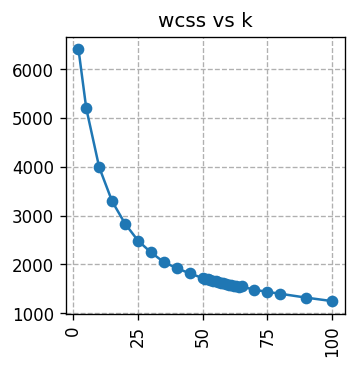

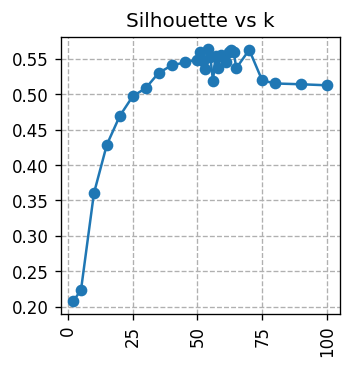

In [ ]:
# plto WCSS & Silhouette to gauge at best K
plot_clust_metric(df_results, "wcss")
plot_clust_metric(df_results, "Silhouette")

## Cluster

In [ ]:
# imports
from sklearn import preprocessing
from sklearn.cluster import KMeans

# variables
k = 53
# k = 63
do_cosine_dist = False
ALPHA = 0.01

# functions

kms = list()
k_labels = list()

for i, embedding_type in enumerate(embedding_types):
    print(f"Clustering for embedding type: {embedding_type}")
    
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    if do_cosine_dist:
        km.fit(preprocessing.normalize(e_trains[i]))
    else:
        km.fit(e_trains[i])

    kms.append(km)
    k_labels.append(km.labels_)

Clustering for embedding type: ft
Clustering for embedding type: pt
Clustering for embedding type: raw_normed


In [ ]:
# Predict clusters for test data
test_preds = list()
for i, embedding_type in enumerate(embedding_types):
    print(f"Predicting clusters for embedding type: {embedding_type}")
    km = kms[i]
    e_test = e_tests[i]
    # predict cluster for new data
    if do_cosine_dist:
        test_pred_clusters = km.predict(preprocessing.normalize(e_test))
    else:
        test_pred_clusters = km.predict(e_test)
    test_preds.append(test_pred_clusters)

Predicting clusters for embedding type: ft
Predicting clusters for embedding type: pt
Predicting clusters for embedding type: raw_normed


### Run Enrichment

In [ ]:
ALPHA = 0.05
# ALPHA = 1

clust_to_enrs = list()

for i, embedding_type in enumerate(embedding_types):
    print(f"Enrichment analysis for embedding type: {embedding_type}")
    km = kms[i]
    df_train = df_trains[i]

    # enrichment analysis of crun_hypergeom_enrichmentluster labels!
    df_k_enrich = run_hypergeom_enrichment(
        km.labels_, df_train["doid_id"].to_list()
    )

    # filter significant enrichments
    df_k_enrich_sig = df_k_enrich[df_k_enrich["p_value"] <= ALPHA]

    # Create a map: {cluster_id: [list of enriched labels]}
    clust_to_enr = dict()
    for cluster_id in np.unique(df_k_enrich_sig["cluster"]):
        # Collect all disease DOIDs that are significantly enriched in this cluster
        diseases = df_k_enrich_sig[df_k_enrich_sig["cluster"] == cluster_id][
            "disease"
        ].to_list()
        clust_to_enr[int(cluster_id)] = [str(d) for d in diseases]

    clust_to_enrs.append(clust_to_enr)

Enrichment analysis for embedding type: ft
Enrichment analysis for embedding type: pt
Enrichment analysis for embedding type: raw_normed


In [ ]:
from itertools import combinations

# Semantic Similarity Validation
# ref: Clustering rare diseases within an ontology-enriched knowledge graph
# sample 100 x sets of average cluster size and check average pairwise semantic similarity
# then perform one way t-student test to check statistical significance to statistically 
# evaluate the difference in the mean average semantic similarity between the disease clusters

# real cluster semantic similarity
ss_clusters = list()
n_diseases = list()
clust_to_ss = list()
rnd_ss_clusters = list()

for i, embedding_type in enumerate(embedding_types):
    print(f"Semantic similarity for embedding type: {embedding_type}")
    
    ss_cluster = list()
    n_diseases = list()
    clust_to_ss_i = dict()

    clust_to_enr_dis = clust_to_enrs[i]

    flatten = lambda x : [x_i for x_sub in x for x_i in x_sub]

    for c_i, enr_i in clust_to_enr_dis.items():

        n_diseases.append(len(enr_i))

        if len(enr_i)==1:
            continue
        
        _ss_clust = list()
        for d1, d2 in combinations(enr_i, 2):
            _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
            _ss_clust.append(float(_lin_sim))

        clust_to_ss_i[c_i] = float(np.mean(_ss_clust))
        ss_cluster.append(_ss_clust)

    # random cluster semantic similarity
    mean_clust_size = int(round(np.mean(n_diseases)))

    rnd_ss_cluster = list()
    for _ in tqdm(range(10)):
        for _ in range(len(clust_to_enr)):
            # pick N random diseases
            _dis_samp = np.random.choice(dis_ord, size=mean_clust_size, replace=False)
            
            _ss_clust = list()
            for d1, d2 in combinations(_dis_samp, 2):
                _lin_sim = _do_df_ic.query("(do1==@d1 & do2==@d2) or (do1==@d2 & do2==@d1)")["lin"].values[0]
                _ss_clust.append(_lin_sim)

            rnd_ss_cluster.append(_ss_clust)

    ss_clusters.append(ss_cluster)
    n_diseases.append(n_diseases)
    clust_to_ss.append(clust_to_ss_i)
    rnd_ss_clusters.append(rnd_ss_cluster)

Semantic similarity for embedding type: ft


100%|██████████| 10/10 [00:06<00:00,  1.56it/s]


Semantic similarity for embedding type: pt


100%|██████████| 10/10 [00:17<00:00,  1.79s/it]


Semantic similarity for embedding type: raw_normed


100%|██████████| 10/10 [00:10<00:00,  1.01s/it]


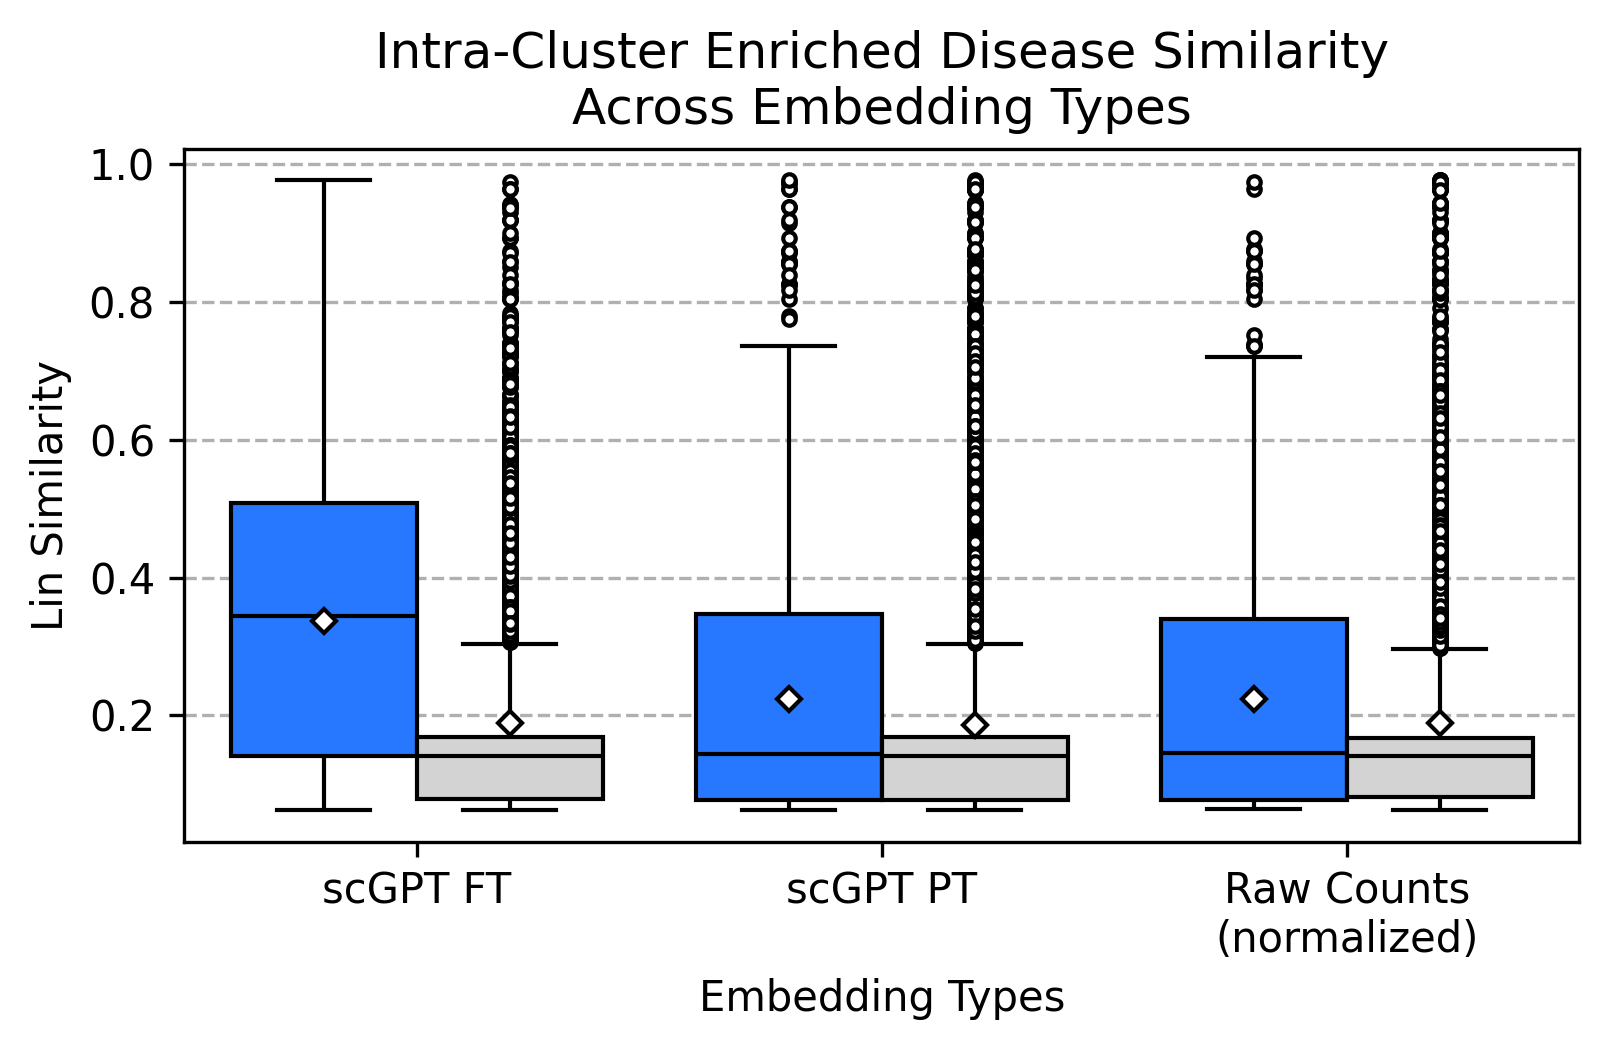

In [ ]:
data_plot = list()
for i, embedding_type in enumerate(embedding_types):
    for ss in ss_clusters[i]:
        for v in ss:
            data_plot.append({
                "Embedding": embedding_type,
                "Type": "Real clusters",
                "Lin similarity": v
            })
    for ss in rnd_ss_clusters[i]:
        for v in ss:
            data_plot.append({
                "Embedding": embedding_type,
                "Type": "Random clusters",
                "Lin similarity": v
            })


map_replace_name = {"ft":"scGPT FT", "pt":"scGPT PT", "raw_normed":"Raw Counts\n(normalized)"}

df_plot = pd.DataFrame(data_plot)

df_plot["Embedding"] = df_plot["Embedding"].map(map_replace_name)

plt.figure(figsize=(6,3), dpi=300)
import seaborn as sns
palette={"Real clusters": "#2778ff", "Random clusters": "lightgrey"}
meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 4,
    }
flierprops={
        "marker": "o",
        "markersize": 3,
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "alpha": 1.0,
    }
boxprops = {"edgecolor": "black"}
# sns.violinplot(data=df_plot, x="Embedding", y="Lin similarity", hue="Type", split=True, inner="quart", palette=palette, zorder=3)
sns.boxplot(data=df_plot, x="Embedding", y="Lin similarity", hue="Type", 
            palette=palette, 
            meanprops=meanprops, 
            flierprops=flierprops,
            boxprops=boxprops,
            showmeans=True,
            saturation=1.0,

    whiskerprops={"color": "black"},
    capprops={"color": "black"},
    medianprops={"color": "black"},
    zorder=3,
    legend=False)
plt.title("Intra-Cluster Enriched Disease Similarity\nAcross Embedding Types")
plt.grid(linestyle="--", axis="y", zorder=-3)
plt.xlabel("Embedding Types")
plt.ylabel("Lin Similarity")
# plt.legend(None)
plt.show()  

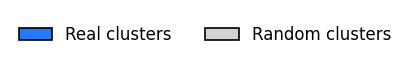

In [ ]:
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=palette["Real clusters"], edgecolor="black", label="Real clusters"),
    Patch(facecolor=palette["Random clusters"], edgecolor="black", label="Random clusters"),
]

plt.figure(figsize=(3, 0.5), dpi=120)
plt.legend(
    handles=legend_elements,
    loc="center",
    frameon=False,
    ncol=2
)
plt.axis("off")
plt.show()


Student’s t-test (one-sided, real > random): t = 15.784, p = 0.0000


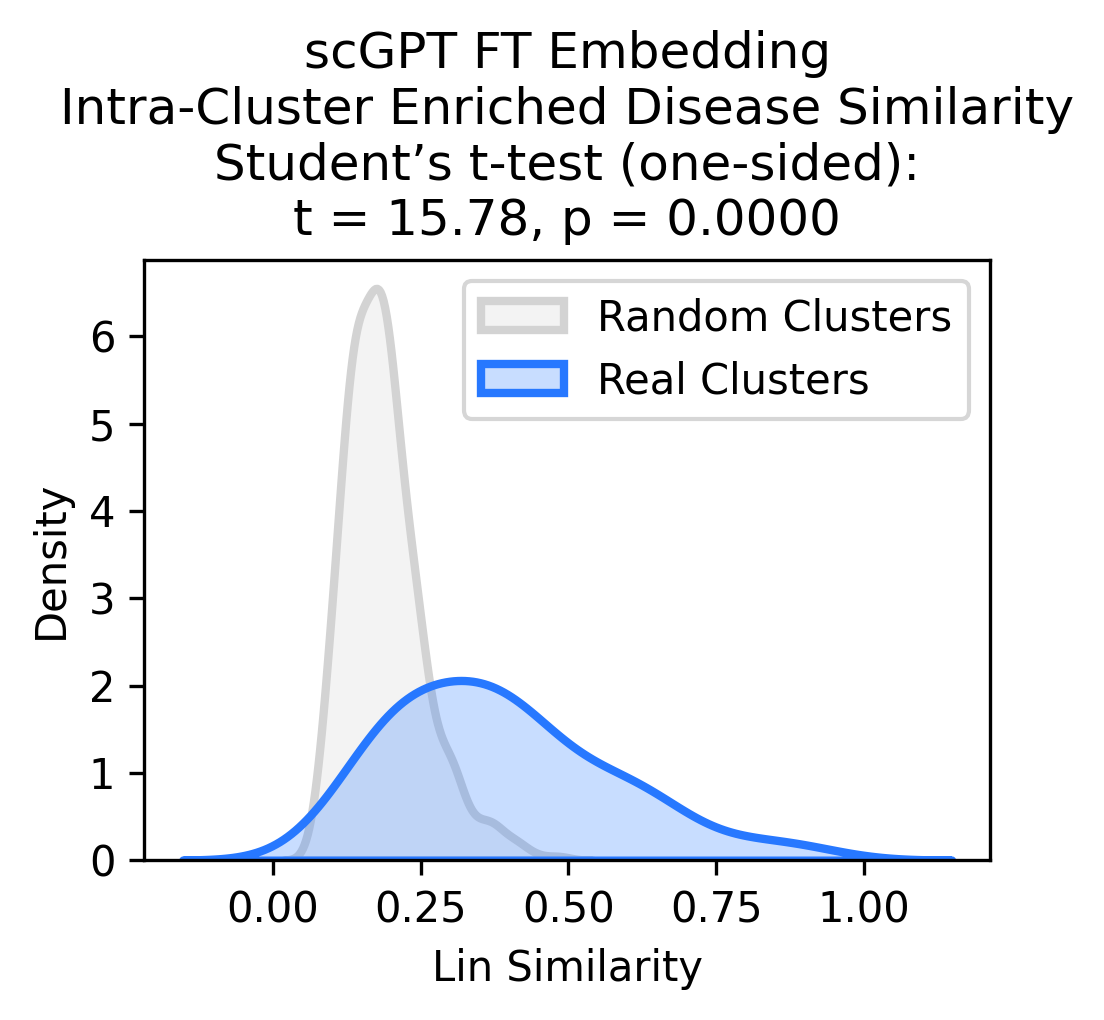

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

dpi = 300

# Statistical test on per-cluster average similarities
real_avgs = [float(np.mean(x)) for x in ss_clusters[0]]
rand_avgs = [float(np.mean(x)) for x in rnd_ss_clusters[0]]

t_stat, p_val_two_sided = ttest_ind(real_avgs, rand_avgs, equal_var=True)
p_val_one_sided = p_val_two_sided / 2 if t_stat > 0 else 1.0

print(f"Student’s t-test (one-sided, real > random): t = {t_stat:.3f}, p = {p_val_one_sided:.4f}")

# Plot KDEs
plt.figure(figsize=(3.5, 3.5), dpi =dpi)

palette={"Real clusters": "#2778ff", "Random clusters": "lightgrey"}

sns.kdeplot(rand_avgs, fill=True, label='Random Clusters', linewidth=2, color=palette["Random clusters"], )
sns.kdeplot(real_avgs, fill=True, label='Real Clusters', linewidth=2, color=palette["Real clusters"], )

# Title with test statistic
plt.title(f'scGPT FT Embedding\nIntra-Cluster Enriched Disease Similarity\nStudent’s t-test (one-sided):\nt = {t_stat:.2f}, p = {p_val_one_sided:.4f}')
plt.xlabel('Lin Similarity')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

<Axes: ylabel='Density'>

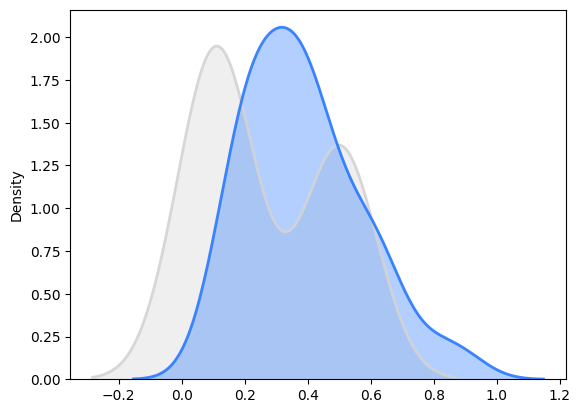

In [ ]:
# FILL (alpha you want for area)
sns.kdeplot(
    rand_avgs,
    fill=True,
    color=palette["Random clusters"],
    alpha=0.35,
    linewidth=0,
)

# LINE (alpha you want for outline)
sns.kdeplot(
    rand_avgs,
    fill=False,
    color=palette["Random clusters"],
    linewidth=2,
    alpha=0.9,
    label="Random Clusters",
)


# FILL
sns.kdeplot(
    real_avgs,
    fill=True,
    color=palette["Real clusters"],
    alpha=0.35,
    linewidth=0,
)

# LINE
sns.kdeplot(
    real_avgs,
    fill=False,
    color=palette["Real clusters"],
    linewidth=2,
    alpha=0.9,
    label="Real Clusters",
)
